# Transformada Discreta del Coseno

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [12]:
img = cv2.imread("img/lena.jpeg", cv2.IMREAD_GRAYSCALE)
img = np.float32(img)

dct = cv2.dct(img)
dct_abs = np.abs(dct)
dct_spec = np.log(dct_abs + 1)

fft = np.fft.fft2(img)
fft_2 = np.fft.fftshift(fft)
fft_abs = np.abs(fft)
fft_spec = np.log(fft_abs + 1)

fft_abs_2 = np.abs(fft_2)
fft_spec_2 = np.log(fft_abs_2 + 1)

n,m = fft_spec.shape
fft_spec_seg = fft_spec_2[0:n//2, :]#0:m//2]

fft_phase = np.angle(fft_2)

In [13]:
h = ( (fft_phase + np.pi) / (2 * np.pi) * 179 ).astype(np.uint8)
s = np.uint8(255 * np.ones_like(fft_phase))
v = cv2.normalize(fft_spec_2, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

mag_phase = cv2.merge([h, s, v])
mag_phase_RGB = cv2.cvtColor(mag_phase, cv2.COLOR_HSV2RGB)

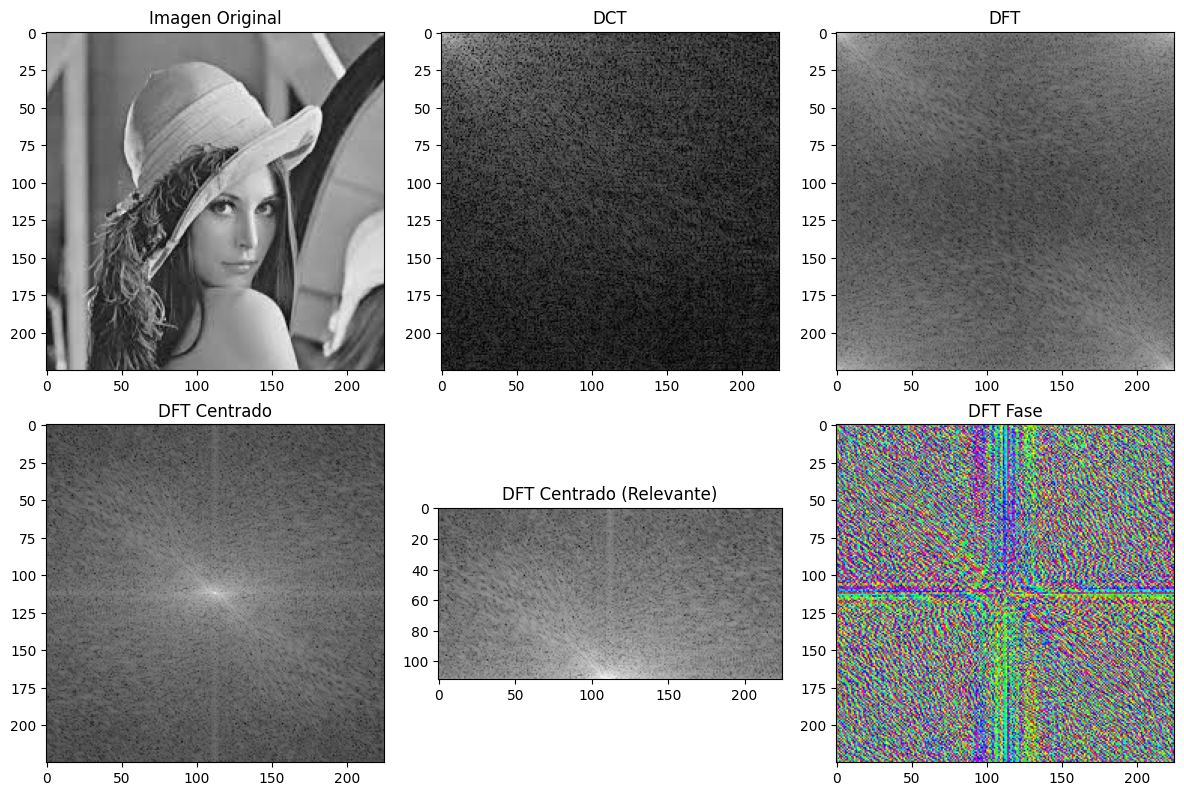

In [14]:
fig, axs = plt.subplots(2,3, figsize=(12,8))

axs[0,0].imshow(img, cmap="gray")
axs[0,0].set_title("Imagen Original")

axs[0,1].imshow(dct_spec, cmap="gray")
axs[0,1].set_title("DCT")

axs[0,2].imshow(fft_spec, cmap="gray")
axs[0,2].set_title("DFT")

axs[1,0].imshow(fft_spec_2, cmap="gray")
axs[1,0].set_title("DFT Centrado")

axs[1,1].imshow(fft_spec_seg, cmap="gray")
axs[1,1].set_title("DFT Centrado (Relevante)")

axs[1,2].imshow(fft_phase, cmap="hsv")
axs[1,2].set_title("DFT Fase")

plt.tight_layout()
plt.show()

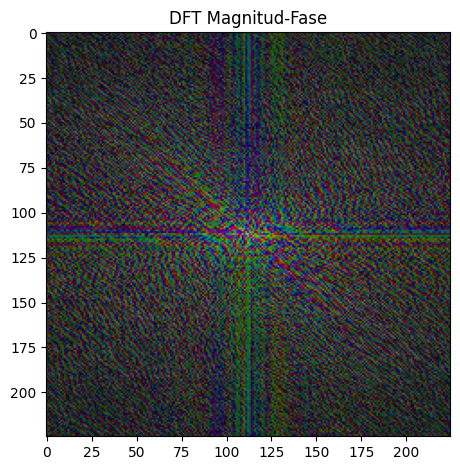

In [15]:
plt.imshow(mag_phase_RGB)
plt.title("DFT Magnitud-Fase")
plt.tight_layout()
plt.show()